<a href="https://colab.research.google.com/github/sumaiyasazzad/skillmorph.sumaiyasazzad/blob/main/conference1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

train = pd.read_parquet('/content/drive/MyDrive/skillmorph/train-00000-of-00001.parquet')
valid = pd.read_parquet('/content/drive/MyDrive/skillmorph/validation-00000-of-00001.parquet')
test = pd.read_parquet('/content/drive/MyDrive/skillmorph/test-00000-of-00001.parquet')

In [7]:
print("Train Shape :", train.shape)
print("Validation Shape :", valid.shape)
print("Test Shape :", test.shape)

print(train.columns.tolist())

Train Shape : (1073851, 42)
Validation Shape : (134232, 42)
Test Shape : (134231, 42)
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label', 'attack_class', 'label']


In [8]:
train.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label,attack_class,label
0,0.00,47,64.00,5779.746173,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0,0,0,0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,1.00,1.00,59200,592,592,592.00,0.000000,592.00,0.000174,100,0.000000,Mirai-greeth_flood,Mirai,1
1,10.20,6,63.36,1974.301113,0.00,0.01,0.01,0.00,0.48,0.0,0.0,48,1,0,1,0.0,0.01,0.00,0.0,0.0,0.0,0.0,0.50,0.00,0.0,0.01,0.0,0.0,0.99,0.99,91192,60,1514,911.92,583.720212,911.92,0.000507,100,340729.286465,DDoS-ACK_Fragmentation,DDoS,1
2,1.00,47,65.23,2090.525036,0.00,0.00,0.00,0.01,0.02,0.0,0.0,2,0,0,0,0.0,0.00,0.03,0.0,0.0,0.0,0.0,0.02,0.03,0.0,0.00,0.0,0.0,1.00,1.00,56660,74,592,566.60,111.302119,566.60,0.000480,100,12388.161616,Mirai-greeth_flood,Mirai,1
3,20.12,6,65.74,26638.958399,0.00,0.99,0.00,0.00,0.01,0.0,0.0,1,99,0,0,0.0,0.01,0.00,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.00,0.0,0.0,1.00,1.00,6006,60,66,60.06,0.600000,60.06,0.000038,100,0.360000,DDoS-SynonymousIP_Flood,DDoS,1
4,4.00,47,64.42,1854.663960,0.01,0.09,0.01,0.01,0.02,0.0,0.0,2,9,1,1,0.0,0.10,0.00,0.0,0.0,0.0,0.0,0.11,0.00,0.0,0.02,0.0,0.0,0.98,0.98,51211,54,578,512.11,171.336629,512.11,0.000541,100,29356.240303,Mirai-greip_flood,Mirai,1


In [9]:
for col in ['Label', 'label', 'attack_class']:
    if col in train.columns:
        print(f"\n{col}")
        print(train[col].value_counts())


Label
Label
BenignTraffic              159990
DDoS-UDP_Flood              40192
DoS-HTTP_Flood              40071
Mirai-greeth_flood          40058
Recon-HostDiscovery         40038
DoS-TCP_Flood               40035
DDoS-ICMP_Fragmentation     40030
MITM-ArpSpoofing            40029
Recon-PortScan              40028
VulnerabilityScan           40019
DNS_Spoofing                40014
DDoS-SynonymousIP_Flood     40003
DDoS-SYN_Flood              39975
DDoS-ACK_Fragmentation      39973
DDoS-TCP_Flood              39973
Recon-OSScan                39942
DDoS-UDP_Fragmentation      39929
Mirai-udpplain              39927
DDoS-ICMP_Flood             39923
DoS-UDP_Flood               39913
Mirai-greip_flood           39912
DoS-SYN_Flood               39906
DDoS-HTTP_Flood             23047
DDoS-SlowLoris              18797
DictionaryBruteForce        10457
BrowserHijacking             4642
CommandInjection             4336
SqlInjection                 4206
XSS                          3090
B

In [10]:
print("Train Shape :", train.shape)
print("Validation Shape :", valid.shape)
print("Test Shape :", test.shape)

Train Shape : (1073851, 42)
Validation Shape : (134232, 42)
Test Shape : (134231, 42)


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073851 entries, 0 to 1073850
Data columns (total 42 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Header_Length    1073851 non-null  float64
 1   Protocol Type    1073851 non-null  int64  
 2   Time_To_Live     1073851 non-null  float64
 3   Rate             1073851 non-null  float64
 4   fin_flag_number  1073851 non-null  float64
 5   syn_flag_number  1073851 non-null  float64
 6   rst_flag_number  1073851 non-null  float64
 7   psh_flag_number  1073851 non-null  float64
 8   ack_flag_number  1073851 non-null  float64
 9   ece_flag_number  1073851 non-null  float64
 10  cwr_flag_number  1073851 non-null  float64
 11  ack_count        1073851 non-null  int64  
 12  syn_count        1073851 non-null  int64  
 13  fin_count        1073851 non-null  int64  
 14  rst_count        1073851 non-null  int64  
 15  HTTP             1073851 non-null  float64
 16  HTTPS            1

In [12]:
print("Train Missing Values:")
print(train.isnull().sum().sum())

print("\nValidation Missing Values:")
print(valid.isnull().sum().sum())

print("\nTest Missing Values:")
print(test.isnull().sum().sum())

Train Missing Values:
0

Validation Missing Values:
0

Test Missing Values:
0


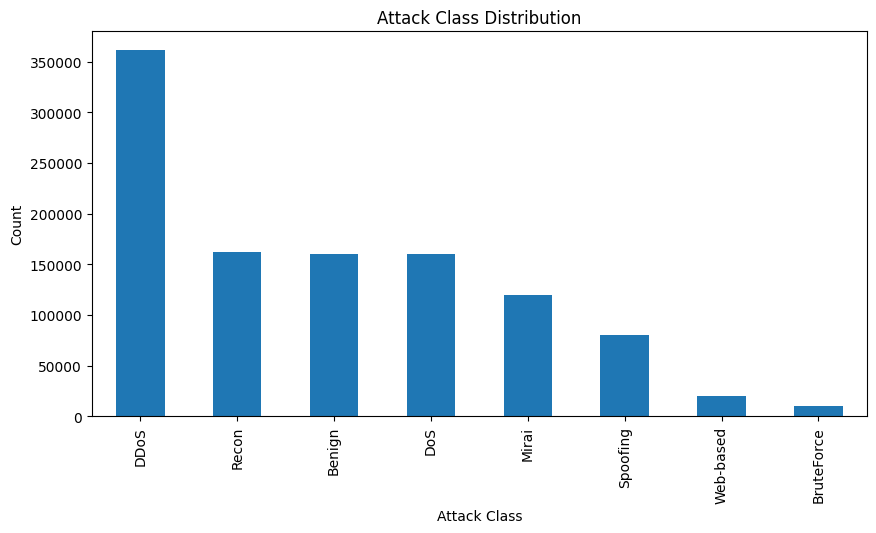

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

train['attack_class'].value_counts().plot(kind='bar')

plt.title('Attack Class Distribution')
plt.xlabel('Attack Class')
plt.ylabel('Count')

plt.show()

In [14]:
class_dist = (
    train['attack_class']
    .value_counts(normalize=True)
    * 100
)

print(class_dist)

attack_class
DDoS          33.695736
Recon         15.074438
Benign        14.898715
DoS           14.892662
Mirai         11.165143
Spoofing       7.453827
Web-based      1.845694
BruteForce     0.973785
Name: proportion, dtype: float64


In [16]:
X_train = train.drop(
    columns=['Label','label','attack_class']
)

X_valid = valid.drop(
    columns=['Label','label','attack_class']
)

X_test = test.drop(
    columns=['Label','label','attack_class']
)

y_train = train['attack_class']
y_valid = valid['attack_class']
y_test = test['attack_class']

In [17]:
print("Number of Features:",
      X_train.shape[1])

Number of Features: 39


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_valid = le.transform(y_valid)
y_test = le.transform(y_test)

In [19]:
for i, c in enumerate(le.classes_):
    print(i, "->", c)

0 -> Benign
1 -> BruteForce
2 -> DDoS
3 -> DoS
4 -> Mirai
5 -> Recon
6 -> Spoofing
7 -> Web-based


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)

In [21]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

print(y_train.shape)
print(y_valid.shape)
print(y_test.shape)

(1073851, 39)
(134232, 39)
(134231, 39)
(1073851,)
(134232,)
(134231,)


In [22]:
del train
del valid
del test

In [23]:
print(X_train.shape)
print(np.unique(y_train))
print(le.classes_)

(1073851, 39)
[0 1 2 3 4 5 6 7]
['Benign' 'BruteForce' 'DDoS' 'DoS' 'Mirai' 'Recon' 'Spoofing' 'Web-based']


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.7470479993444137
              precision    recall  f1-score   support

           0       0.58      0.69      0.63     19999
           1       0.77      0.24      0.37      1317
           2       0.79      0.97      0.87     45167
           3       0.86      0.43      0.57     20098
           4       0.99      0.99      0.99     15147
           5       0.67      0.66      0.66     20158
           6       0.57      0.55      0.56      9879
           7       0.58      0.02      0.03      2466

    accuracy                           0.75    134231
   macro avg       0.73      0.57      0.59    134231
weighted avg       0.75      0.75      0.73    134231



In [25]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

print("Weighted F1:", lr_f1)

Weighted F1: 0.7296115576053512


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[13891    38     0     0     0  3919  2146     5]
 [  419   320     0     0     0   422   156     0]
 [    2     0 43658  1403    94     4     6     0]
 [    4     0 11466  8619     5     1     3     0]
 [    0     0    79    41 15021     0     6     0]
 [ 5424    49     1     2     0 13273  1397    12]
 [ 3053     1     3     0     0  1355  5454    13]
 [  966     6     1     0     0   976   476    41]]


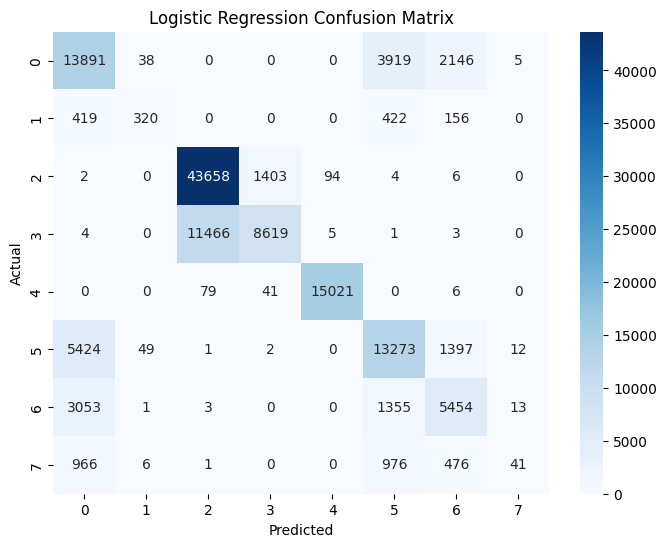

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.8379062958631016
              precision    recall  f1-score   support

           0       0.73      0.82      0.77     19999
           1       0.77      0.32      0.45      1317
           2       0.89      0.91      0.90     45167
           3       0.79      0.76      0.77     20098
           4       1.00      1.00      1.00     15147
           5       0.73      0.75      0.74     20158
           6       0.93      0.87      0.90      9879
           7       0.69      0.27      0.39      2466

    accuracy                           0.84    134231
   macro avg       0.82      0.71      0.74    134231
weighted avg       0.84      0.84      0.83    134231



In [29]:
from sklearn.metrics import f1_score

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted'
)

print("Weighted F1:", rf_f1)

Weighted F1: 0.834881167741041


In [30]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Random Forest Weighted F1:",
      rf_f1)

Random Forest Accuracy: 0.8379062958631016
Random Forest Weighted F1: 0.834881167741041


In [31]:
print(X_train.shape)
print(X_test.shape)

(1073851, 39)
(134231, 39)


In [32]:
print(len(np.unique(y_train)))

8


In [34]:
!pip install xgboost -q

In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

In [36]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=8,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    device="cuda",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=8, ...)

In [37]:
xgb_pred = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [10:36:53] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [38]:
from sklearn.metrics import accuracy_score, f1_score

xgb_acc = accuracy_score(y_test, xgb_pred)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average='weighted'
)

print("XGBoost Accuracy:", xgb_acc)
print("XGBoost Weighted F1:", xgb_f1)

XGBoost Accuracy: 0.8423762022185636
XGBoost Weighted F1: 0.8387698189681613


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.71      0.83      0.76     19999
           1       0.79      0.32      0.46      1317
           2       0.90      0.93      0.91     45167
           3       0.83      0.76      0.79     20098
           4       1.00      1.00      1.00     15147
           5       0.73      0.73      0.73     20158
           6       0.94      0.86      0.90      9879
           7       0.73      0.25      0.37      2466

    accuracy                           0.84    134231
   macro avg       0.83      0.71      0.74    134231
weighted avg       0.84      0.84      0.84    134231



In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(39,)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(8, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
%whos

Variable     Type          Data/Info
------------------------------------
Dense        type          <class 'keras.src.layers.core.dense.Dense'>
Dropout      type          <class 'keras.src.layers.<...>ization.dropout.Dropout'>
Sequential   type          <class 'keras.src.models.sequential.Sequential'>
f1_score     function      <function f1_score at 0x7b8c4bf0f100>
model        Sequential    <Sequential name=sequential, built=True>
np           module        <module 'numpy' from '/us<...>kages/numpy/__init__.py'>


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)

NameError: name 'X_train' is not defined

In [8]:
%whos

Variable         Type              Data/Info
--------------------------------------------
Dense            type              <class 'keras.src.layers.core.dense.Dense'>
Dropout          type              <class 'keras.src.layers.<...>ization.dropout.Dropout'>
Sequential       type              <class 'keras.src.models.sequential.Sequential'>
StandardScaler   type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
f1_score         function          <function f1_score at 0x7b8c4bf0f100>
model            Sequential        <Sequential name=sequential, built=True>
np               module            <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
scaler           StandardScaler    StandardScaler()


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import pandas as pd

train = pd.read_parquet('/content/drive/MyDrive/skillmorph/train-00000-of-00001.parquet')
valid = pd.read_parquet('/content/drive/MyDrive/skillmorph/validation-00000-of-00001.parquet')
test = pd.read_parquet('/content/drive/MyDrive/skillmorph/test-00000-of-00001.parquet')

In [14]:
X_train = train.drop(columns=['Label','label','attack_class'])
X_valid = valid.drop(columns=['Label','label','attack_class'])
X_test  = test.drop(columns=['Label','label','attack_class'])

y_train = train['attack_class']
y_valid = valid['attack_class']
y_test  = test['attack_class']

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_valid = le.transform(y_valid)
y_test = le.transform(y_test)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)

In [17]:
print(X_train_scaled.shape)
print(y_train.shape)

(1073851, 39)
(1073851,)


In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=20,
    batch_size=1024,
    verbose=1
)

Epoch 1/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7654 - loss: 0.5643 - val_accuracy: 0.7931 - val_loss: 0.4881
Epoch 2/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7910 - loss: 0.4969 - val_accuracy: 0.7996 - val_loss: 0.4726
Epoch 3/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7959 - loss: 0.4848 - val_accuracy: 0.8015 - val_loss: 0.4640
Epoch 4/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7982 - loss: 0.4771 - val_accuracy: 0.8022 - val_loss: 0.4603
Epoch 5/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8000 - loss: 0.4724 - val_accuracy: 0.8036 - val_loss: 0.4577
Epoch 6/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8017 - loss: 0.4680 - val_accuracy: 0.8073 - val_loss: 0.4532
Epoch 7/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8035 - loss: 0.4638 - val_accuracy: 0.8094 - val_loss: 0.4465
Epoch 8/20
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8072 - loss: 0.4567 -

In [20]:
test_loss, test_acc = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("DNN Accuracy:", test_acc)

DNN Accuracy: 0.8284673690795898


In [21]:
import numpy as np
from sklearn.metrics import f1_score

dnn_pred = np.argmax(
    model.predict(X_test_scaled, verbose=0),
    axis=1
)

dnn_f1 = f1_score(
    y_test,
    dnn_pred,
    average='weighted'
)

print("DNN Weighted F1:", dnn_f1)

DNN Weighted F1: 0.823488036501831


In [22]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    objective='multi:softprob',
    num_class=8,
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cuda',
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_class=8, ...)

In [23]:
xgb_tuned_pred = xgb_tuned.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [11:28:42] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [24]:
from sklearn.metrics import accuracy_score, f1_score

xgb_tuned_acc = accuracy_score(y_test, xgb_tuned_pred)

xgb_tuned_f1 = f1_score(
    y_test,
    xgb_tuned_pred,
    average='weighted'
)

print("Tuned XGB Accuracy:", xgb_tuned_acc)
print("Tuned XGB Weighted F1:", xgb_tuned_f1)

Tuned XGB Accuracy: 0.8522993943276889
Tuned XGB Weighted F1: 0.8495156189329458


In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    xgb_tuned_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

      Benign       0.73      0.84      0.78     19999
  BruteForce       0.80      0.36      0.50      1317
        DDoS       0.90      0.93      0.92     45167
         DoS       0.83      0.77      0.80     20098
       Mirai       1.00      1.00      1.00     15147
       Recon       0.75      0.75      0.75     20158
    Spoofing       0.94      0.87      0.90      9879
   Web-based       0.72      0.32      0.44      2466

    accuracy                           0.85    134231
   macro avg       0.84      0.73      0.76    134231
weighted avg       0.85      0.85      0.85    134231



In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    xgb_tuned_pred
)

print(cm)

[[16733    34     0     0     0  2929   245    58]
 [  294   480     0     0     0   492    19    32]
 [    1     0 42042  3120     3     1     0     0]
 [    0     0  4539 15558     1     0     0     0]
 [    0     0    30     1 15116     0     0     0]
 [ 4629    61     0     0     0 15069   238   161]
 [  649     8     0     0     0   554  8618    50]
 [  465    14     0     0     0  1105    93   789]]


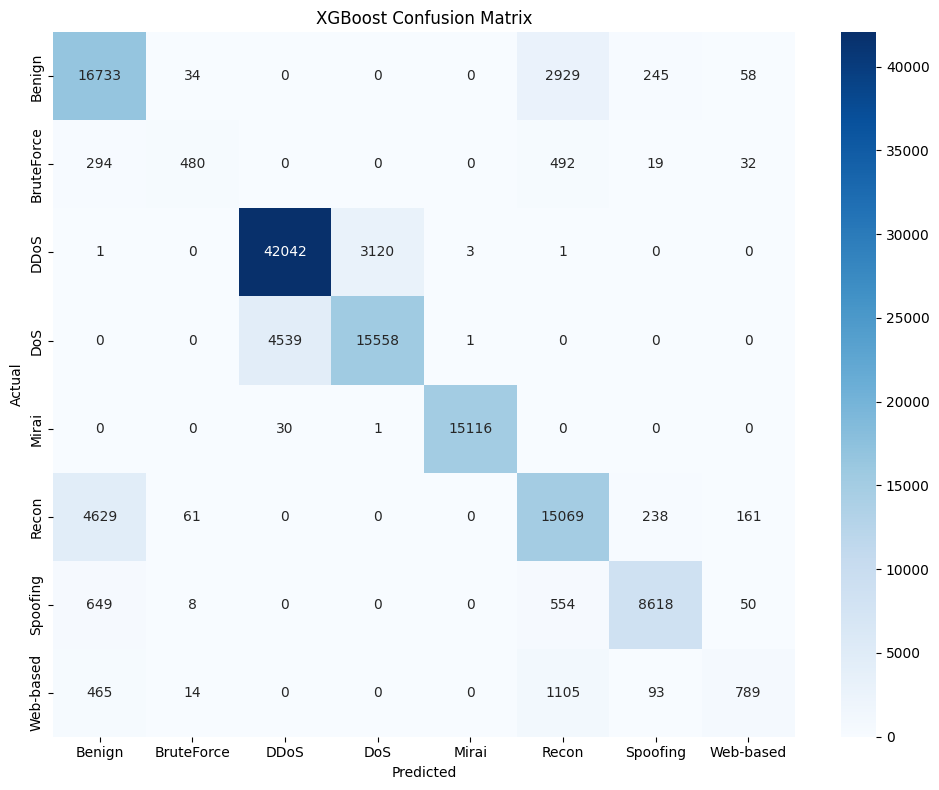

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

In [28]:
plt.savefig(
    "xgb_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [29]:
!pip install shap -q

In [30]:
import shap
import numpy as np

In [32]:
sample_idx = np.random.choice(
    X_test.shape[0],
    2000,
    replace=False
)

X_sample = X_test.iloc[sample_idx]

In [33]:
explainer = shap.TreeExplainer(
    xgb_tuned
)

shap_values = explainer.shap_values(
    X_sample
)

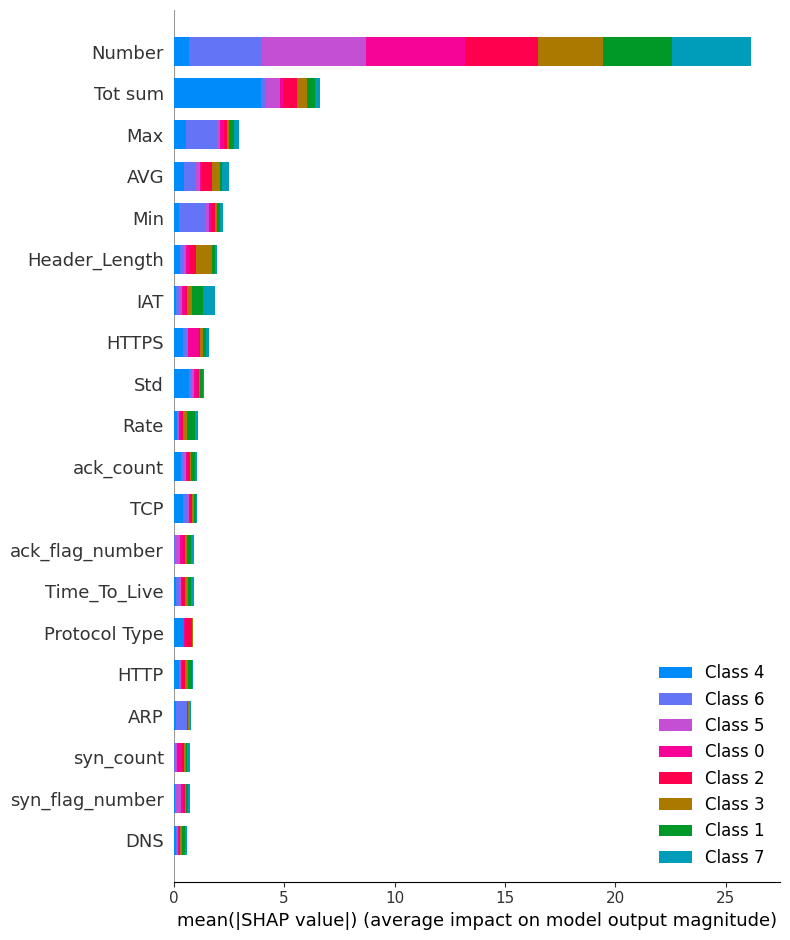

In [34]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

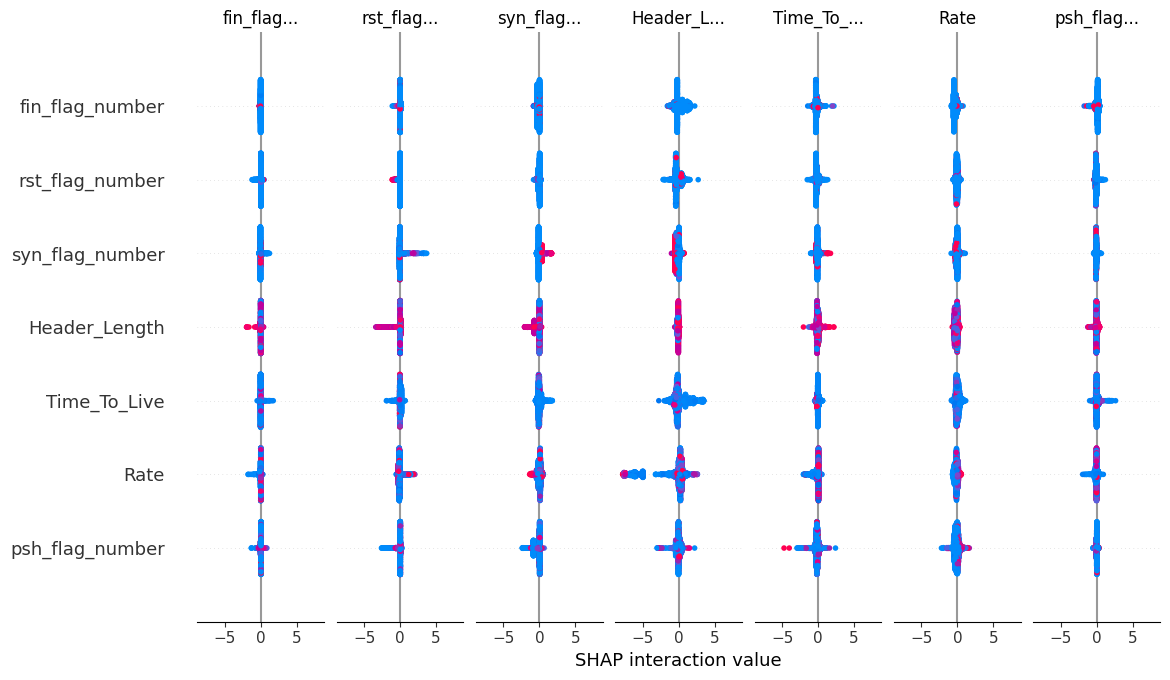

In [35]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [38]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(2000, 39, 8)


In [39]:
import pandas as pd
import numpy as np

importance = np.abs(shap_values).mean(axis=(0, 2))

feature_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

          Feature  Importance
37         Number    3.267465
30        Tot sum    0.826534
32            Max    0.369058
33            AVG    0.311138
31            Min    0.277224
0   Header_Length    0.244575
36            IAT    0.233044
16          HTTPS    0.202039
34            Std    0.173442
3            Rate    0.138003


In [40]:
top10_features = (
    feature_importance
    .head(10)['Feature']
    .tolist()
)

print(top10_features)

['Number', 'Tot sum', 'Max', 'AVG', 'Min', 'Header_Length', 'IAT', 'HTTPS', 'Std', 'Rate']


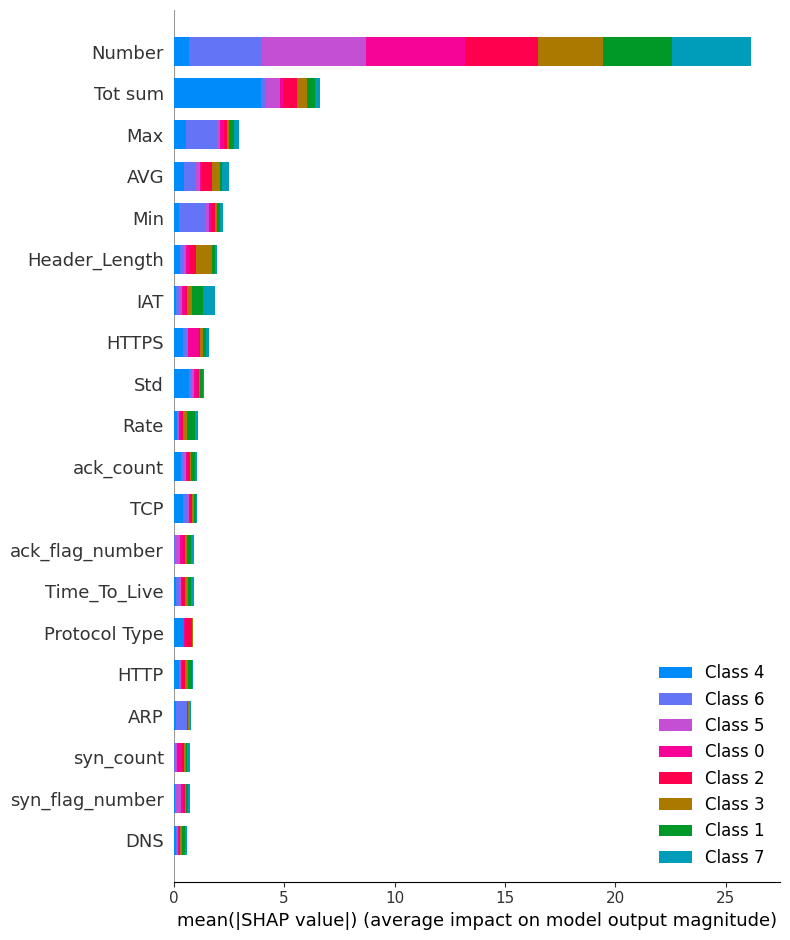

In [41]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

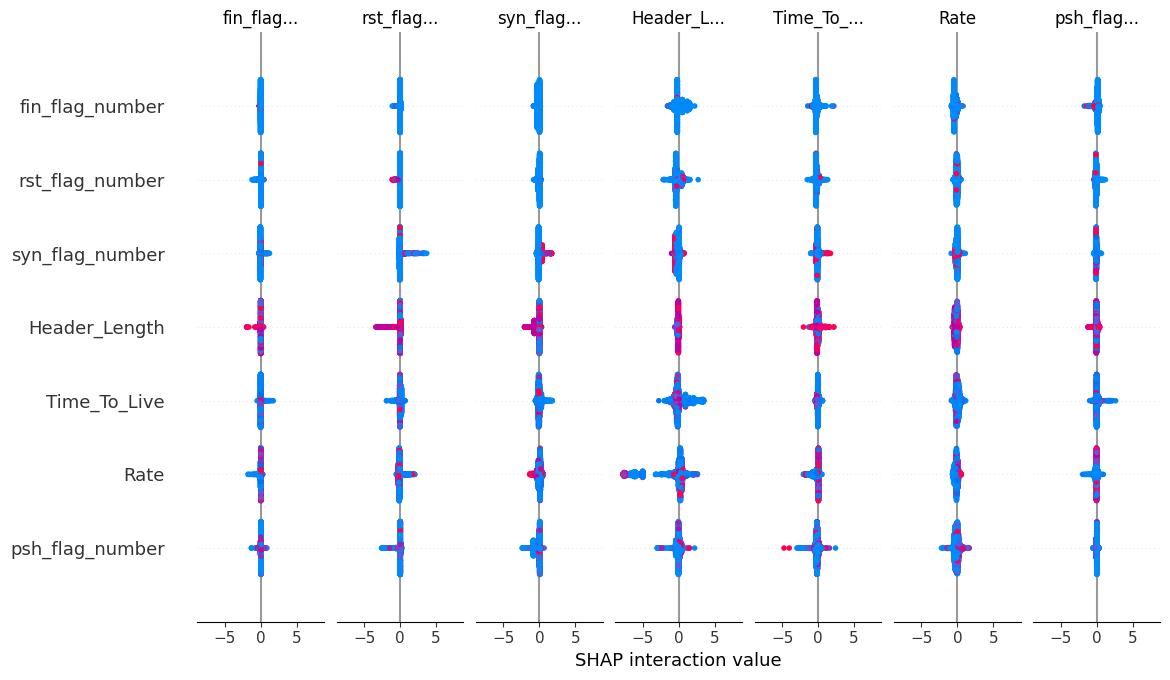

In [42]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [43]:
X_train_top10 = X_train[top10_features]
X_test_top10 = X_test[top10_features]

In [44]:
xgb_top10 = XGBClassifier(
    objective='multi:softprob',
    num_class=8,
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cuda',
    random_state=42
)

xgb_top10.fit(
    X_train_top10,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_class=8, ...)

In [45]:
pred_top10 = xgb_top10.predict(X_test_top10)

In [46]:
from sklearn.metrics import accuracy_score, f1_score

top10_acc = accuracy_score(
    y_test,
    pred_top10
)

top10_f1 = f1_score(
    y_test,
    pred_top10,
    average='weighted'
)

print("Top10 Accuracy:", top10_acc)
print("Top10 Weighted F1:", top10_f1)

Top10 Accuracy: 0.8135825554454634
Top10 Weighted F1: 0.8070609230561152


In [49]:
%whos

Variable                Type              Data/Info
---------------------------------------------------
Dense                   type              <class 'keras.src.layers.core.dense.Dense'>
Dropout                 type              <class 'keras.src.layers.<...>ization.dropout.Dropout'>
LabelEncoder            type              <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
Sequential              type              <class 'keras.src.models.sequential.Sequential'>
StandardScaler          type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
XGBClassifier           type              <class 'xgboost.sklearn.XGBClassifier'>
X_sample                DataFrame                 Header_Length  Pr<...>n[2000 rows x 39 columns]
X_test                  DataFrame                 Header_Length  Pr<...>134231 rows x 39 columns]
X_test_scaled           ndarray           134231x39: 5235009 elems, type `float64`, 41880072 bytes (39.93994903564453 Mb)
X_test_top10            D

In [50]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    xgb_tuned_pred,
    target_names=le.classes_
)

print(report)

              precision    recall  f1-score   support

      Benign       0.73      0.84      0.78     19999
  BruteForce       0.80      0.36      0.50      1317
        DDoS       0.90      0.93      0.92     45167
         DoS       0.83      0.77      0.80     20098
       Mirai       1.00      1.00      1.00     15147
       Recon       0.75      0.75      0.75     20158
    Spoofing       0.94      0.87      0.90      9879
   Web-based       0.72      0.32      0.44      2466

    accuracy                           0.85    134231
   macro avg       0.84      0.73      0.76    134231
weighted avg       0.85      0.85      0.85    134231



In [51]:
with open("classification_report.txt", "w") as f:
    f.write(report)

In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    xgb_tuned_pred
)

print(cm)

[[16733    34     0     0     0  2929   245    58]
 [  294   480     0     0     0   492    19    32]
 [    1     0 42042  3120     3     1     0     0]
 [    0     0  4539 15558     1     0     0     0]
 [    0     0    30     1 15116     0     0     0]
 [ 4629    61     0     0     0 15069   238   161]
 [  649     8     0     0     0   554  8618    50]
 [  465    14     0     0     0  1105    93   789]]


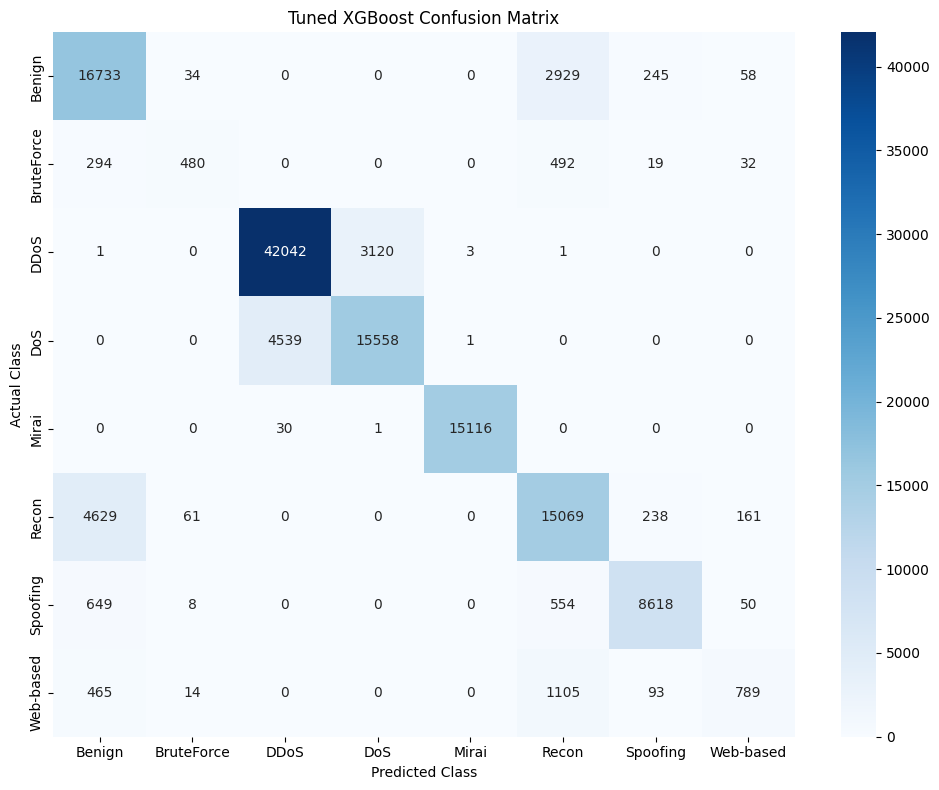

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Tuned XGBoost Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

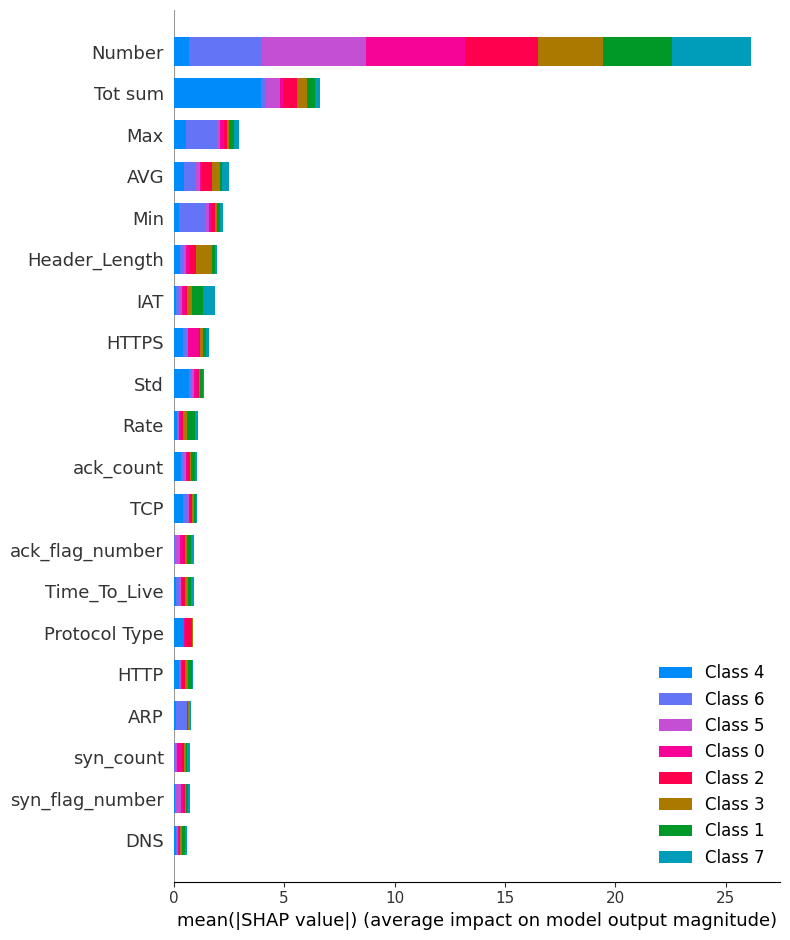

In [54]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

plt.savefig(
    "shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

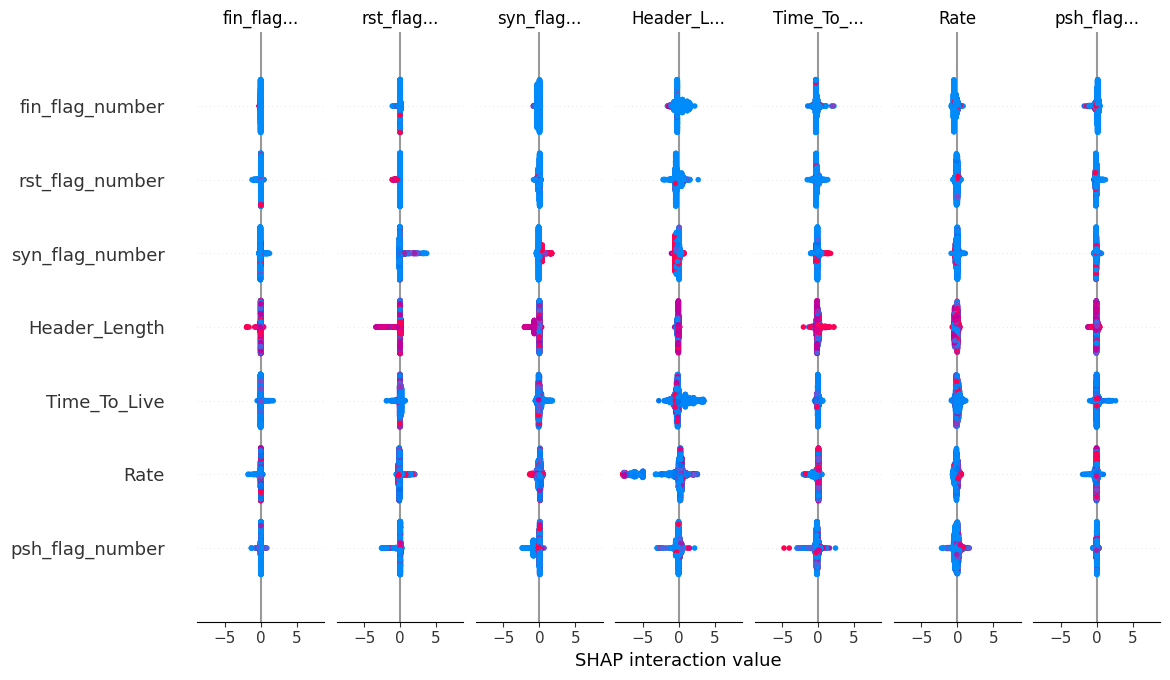

In [55]:
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'DNN',
        'XGBoost',
        'Tuned XGBoost',
        'XGBoost Top10 Features'
    ],
    'Accuracy':[
        0.7470,
        0.8379,
        0.8285,
        0.8424,
        0.8523,
        0.8136
    ],
    'Weighted F1':[
        0.7296,
        0.8349,
        0.8235,
        0.8388,
        0.8495,
        0.8071
    ]
})

results

,Model,Accuracy,Weighted F1
0,Logistic Regression,0.7470,0.7296
1,Random Forest,0.8379,0.8349
2,DNN,0.8285,0.8235
3,XGBoost,0.8424,0.8388
4,Tuned XGBoost,0.8523,0.8495
5,XGBoost Top10 Features,0.8136,0.8071


In [57]:
results.to_csv(
    "final_results.csv",
    index=False
)

<Figure size 1000x600 with 0 Axes>

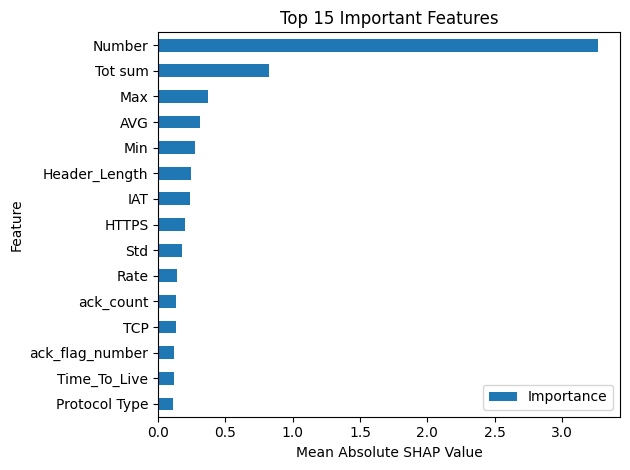

In [58]:
plt.figure(figsize=(10,6))

feature_importance.head(15).sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig(
    "top15_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
xgb_tuned.save_model(
    '/content/drive/MyDrive/ICCIT_2026/xgb_tuned.json'
)

XGBoostError: [12:07:26] /__w/xgboost/xgboost/dmlc-core/src/io/local_filesys.cc:224: Check failed: allow_null:  LocalFileSystem::Open "/content/drive/MyDrive/ICCIT_2026/xgb_tuned.json": No such file or directory
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2c69bc) [0x7b8ad56c69bc]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x13bb1bd) [0x7b8ad67bb1bd]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x13a75d5) [0x7b8ad67a75d5]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGBoosterSaveModel+0x4e) [0x7b8ad55d354e]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7b8c8745ee2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7b8c8745b493]
  [bt] (6) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x98c1) [0x7b8c887928c1]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x8f

In [60]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Getting started.pdf',
 'Phy 1 cncpt book.pdf',
 '69855059-a615-47a6-a797-1e51edcfcaf5_26266_199_202201081954176501__637772686232039013.pdf',
 '5_6206518065329342554.pdf',
 'b.pdf',
 '5_6265033876591085615.pdf',
 'periodic.pdf',
 '1st chapter (EEE-1101).PDF',
 'previous year question.pdf',
 'data table',
 'Data table1.jpg',
 'n.pdf',
 'cover 1.pdf',
 'IMG-20240218-WA0001.jpg',
 'certificate.pdf',
 'certificate..pdf',
 'ananna.pdf',
 'test.csv',
 'Untitled document (1).gdoc',
 'AIBThings2024_HS.pdf',
 '1000121947.jpg',
 'LC CT',
 'IMG-20251213-WA0005.jpg',
 'Classroom',
 'A_Comparative_Study_of_CNN_Architectures_ConvNeXt_.pdf',
 'Untitled document.gdoc',
 'received_1832496654377726 (1).jpeg',
 'received_1832496654377726.jpeg',
 'skillmorph',
 'ICCIT_2026']

In [61]:
import os

print(os.path.exists('/content/drive/MyDrive'))

True


In [62]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'Phy 1 cncpt book.pdf', '69855059-a615-47a6-a797-1e51edcfcaf5_26266_199_202201081954176501__637772686232039013.pdf', '5_6206518065329342554.pdf', 'b.pdf', '5_6265033876591085615.pdf', 'periodic.pdf', '1st chapter (EEE-1101).PDF', 'previous year question.pdf', 'data table', 'Data table1.jpg', 'n.pdf', 'cover 1.pdf', 'IMG-20240218-WA0001.jpg', 'certificate.pdf', 'certificate..pdf', 'ananna.pdf', 'test.csv', 'Untitled document (1).gdoc', 'AIBThings2024_HS.pdf', '1000121947.jpg', 'LC CT', 'IMG-20251213-WA0005.jpg', 'Classroom', 'A_Comparative_Study_of_CNN_Architectures_ConvNeXt_.pdf', 'Untitled document.gdoc', 'received_1832496654377726 (1).jpeg', 'received_1832496654377726.jpeg', 'skillmorph', 'ICCIT_2026']


In [63]:
import os

print(os.path.exists('/content/drive/MyDrive/ICCIT_2026'))

True


In [64]:
xgb_tuned.save_model('/content/drive/MyDrive/ICCIT_2026/xgb_tuned.json')

In [65]:
model.save('/content/drive/MyDrive/ICCIT_2026/dnn_model.keras')

In [66]:
import os

print(os.listdir('/content/drive/MyDrive/ICCIT_2026'))

['xgb_tuned.json', 'dnn_model.keras']


In [67]:
feature_importance.to_csv(
    '/content/drive/MyDrive/ICCIT_2026/shap_feature_importance.csv',
    index=False
)

In [68]:
import pickle

with open(
    '/content/drive/MyDrive/ICCIT_2026/top10_features.pkl',
    'wb'
) as f:
    pickle.dump(top10_features, f)

In [69]:
with open(
    '/content/drive/MyDrive/ICCIT_2026/classification_report.txt',
    'w'
) as f:
    f.write(report)

In [70]:
results.to_csv(
    '/content/drive/MyDrive/ICCIT_2026/final_results.csv',
    index=False
)